In [3]:
from pychrtrace import Compare
import glob
import pyfftw
import multiprocessing
import scipy
scipy.fft.set_global_backend(pyfftw.interfaces.scipy_fft)
pyfftw.interfaces.cache.enable()
pyfftw.config.NUM_THREADS = multiprocessing.cpu_count()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
configs = glob.glob(r'Q:\ChromatinTeam\img_processing_t4\2020-06-15-Exp333_KSB_Elyra_DAPI_TADs_SIM_temp_brdu\Analysis\*.yaml')
print(configs)
for config in configs:
    C = Compare(config)
    C.compare_multi_sc(save_dc=True)

da3\envs\pychrtrace\lib\site-packages\imreg_dft\utils.py:315: RuntimeWarning: overflow encountered in long_scalars
  xidx = corner[1] + jj
C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\imreg_dft\utils.py:312: RuntimeWarning: overflow encountered in long_scalars
  yidx = corner[0] + ii
C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\imreg_dft\imreg.py:465: RuntimeWarning: invalid value encountered in true_divide
  cps = abs(fft.ifft2((f0 * f1.conjugate()) / (abs(f0) * abs(f1) + eps)))
C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\imreg_dft\utils.py:338: RuntimeWarning: invalid value encountered in remainder
  ret %= np.array(array.shape).astype(int)
C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\imreg_dft\utils.py:315: RuntimeWarning: overflow encountered in long_scalars
  xidx = corner[1] + jj
C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\imreg_dft\utils.py:312: RuntimeWarning: overflow encountered i

In [5]:
nucs_1D = pd.read_csv(r"Q:\ChromatinTeam\img_processing_t4\2021-03-17_Exp352_KSB_elyra_SIM_RDs_analysis\2021-03-17_Exp352_1D_nuc_metrics.csv")
rds_1D = pd.read_csv(r"Q:\ChromatinTeam\img_processing_t4\2021-03-17_Exp352_KSB_elyra_SIM_RDs_analysis\2021-03-17_Exp352_1D_rd_metrics.csv")
nucs_1D['sample'] = '1D'
rds_1D['sample'] = '1D'
#nucs = pd.concat([nucs_3D, nucs_5C, nucs_6C])
#rds = pd.concat([rds_3D, rds_5C, rds_6C])

NameError: name 'pd' is not defined

In [5]:
nucs_1D

,Unnamed: 0,id,MAC,PCC,SSIM,ORB_ratio,Area_ratio,IOU,LBP score,Variance ratio,Skew ratio,Kurtosis ratio,sample
0,0,0,0.763122,0.682593,0.255063,0.935345,1.085363,0.744228,0.029612,0.999950,1.000056,1.000113,1D
1,1,1,0.804989,0.726699,0.349959,1.008358,0.912747,0.771825,0.058096,0.999964,1.000040,1.000090,1D
2,2,2,0.692500,0.547861,0.343205,0.900305,1.058488,0.643652,0.032171,0.999966,1.000040,1.000093,1D
3,3,3,0.807448,0.724935,0.425132,0.898522,0.972597,0.750085,0.033880,0.999972,1.000035,1.000099,1D
4,4,4,0.873815,0.830724,0.351705,0.943889,0.954682,0.834329,0.072057,0.999950,1.000040,1.000088,1D
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197,197,0.855616,0.806680,0.418766,0.877655,1.061232,0.820340,0.016795,0.999967,1.000039,1.000084,1D
198,198,198,0.831814,0.761702,0.497459,1.009496,0.995864,0.814533,0.017621,0.999967,1.000028,1.000065,1D
199,199,199,0.878548,0.839131,0.511623,0.976201,0.957398,0.776679,0.026916,0.999976,1.000027,1.000060,1D
200,200,200,0.899641,0.863401,0.479829,0.956142,0.920072,0.864642,0.085610,0.999964,1.000040,1.000094,1D


In [10]:
nucs.groupby('sample').count()

,Unnamed: 0,id,MAC,PCC,SSIM,ORB_ratio,Area_ratio,IOU,LBP score,Variance ratio,Skew ratio,Kurtosis ratio
sample,,,,,,,,,,,,
3D,226,226,226,226,226,226,226,226,226,226,226,226
5C,176,176,176,176,176,176,176,176,176,176,176,176
6C,140,140,140,140,140,140,140,140,140,140,140,140


<AxesSubplot:xlabel='sample', ylabel='PCC'>

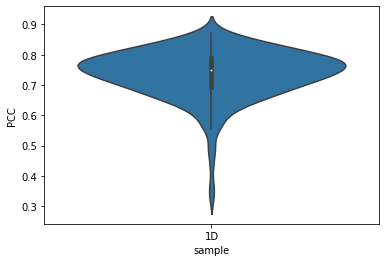

In [23]:
sns.violinplot(data=nucs_1D, y='PCC', x='sample', fliersize=0)

<AxesSubplot:ylabel='PCC'>

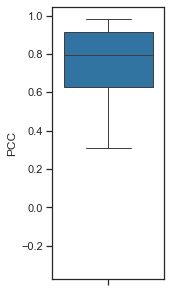

In [69]:
sns.boxplot(data=rds_3D_fix_perm, y='PCC', fliersize=0)

KruskalResult(statistic=310.7774804422579, pvalue=3.2773858329321884e-68)
              3D            5C            6C
3D  1.000000e+00  2.743243e-09  3.769555e-69
5C  2.743243e-09  1.000000e+00  3.574307e-30
6C  3.769555e-69  3.574307e-30  1.000000e+00


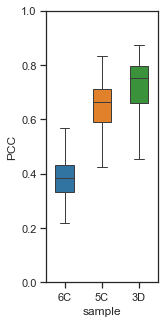

In [24]:
metric='PCC'
data=nucs
sns.set(rc={'figure.figsize':(2,5), 'lines.linewidth': 1})
sns.set_style("ticks")
sns.set_palette('tab10')
ax = sns.boxplot(data=data.sort_values('sample', ascending=False), x='sample', y=metric, width=0.5, fliersize='0')
ax.set_ylim(0,1)
print(kruskal(nucs_3D[metric], nucs_5C[metric], nucs_6C[metric], nan_policy='omit'))
print(posthoc_dunn(data, val_col=metric, group_col='sample'))
plt.savefig(r'Q:\ChromatinTeam\img_processing_t4\2020-06-15-Exp333_KSB_Elyra_DAPI_TADs_SIM_temp_brdu\Analysis\temp_comp_PCC_nucs.pdf', format='pdf', dpi=1200, bbox_inches='tight', transparent=True)

In [71]:
data.query('sample == "6C"')

,Unnamed: 0,id,MAC,PCC,SSIM,ORB_ratio,Area_ratio,IOU,LBP score,Variance ratio,Skew ratio,Kurtosis ratio,sample
0,0,0,0.602923,0.439096,0.321115,0.867324,0.859349,0.510837,0.017672,0.997819,1.002327,1.005678,6C
1,1,1,0.539187,0.379712,0.262328,0.783488,1.186193,0.460857,0.026158,0.998133,1.002094,1.004473,6C
2,2,2,0.582047,0.405691,0.233473,0.725190,1.129605,0.547738,0.031824,0.998018,1.001935,1.004520,6C
3,3,3,0.633828,0.470404,0.276031,0.958009,0.833349,0.503812,0.004433,0.997135,1.002894,1.007945,6C
4,4,4,0.563462,0.370022,0.266072,0.915941,0.868003,0.485321,0.018317,0.997627,1.002391,1.006267,6C
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,59,59,0.542255,0.362550,0.277128,0.963805,0.768365,0.403140,0.050864,0.999075,1.000903,1.002056,6C
60,60,60,0.532614,0.301941,0.075954,0.731937,0.891159,0.485989,0.045740,0.998016,1.002428,1.006750,6C
61,61,61,0.555505,0.324496,0.150463,0.850674,1.097621,0.451460,0.009647,0.999080,1.001302,1.002695,6C
62,62,62,0.488890,0.326119,0.160406,1.390944,0.648239,0.363482,0.049772,0.998268,1.001193,1.001764,6C


In [72]:
print(kruskal(rds_3D['PCC'], rds_5C['PCC'], rds_6C['PCC'], nan_policy='omit'))
posthoc_dunn(rds, val_col='PCC', group_col='sample')

KruskalResult(statistic=52.732355112724235, pvalue=3.5425384964990452e-12)


,3D,5C,6C
3D,1.000000e+00,4.092993e-01,1.060317e-10
5C,4.092993e-01,1.000000e+00,1.036987e-10
6C,1.060317e-10,1.036987e-10,1.000000e+00
